<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/1111111German_Traffic_Sign_Recognition_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from  google.colab import drive
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms,models
from torchvision.transforms import ToTensor,Lambda

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datasetpath="/content/drive/MyDrive/German Traffic Sign Recognition Benchmark dataset.zip"

In [4]:
with zipfile.ZipFile(datasetpath,"r") as z:
  z.extractall("/content/dataset")

EDA

In [5]:
# image count
test_dataset_path = Path("/content/dataset/Test")
train_dataset_path = Path("/content/dataset/Train")
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

test_image_count = sum(1 for file in test_dataset_path.iterdir() if file.suffix.lower() in image_extensions)
train_image_count = sum(1 for file in train_dataset_path.iterdir())
total = 0
for root, dirs, files in os.walk("/content/dataset/Train"):
    total += len(files)

print("Total images train:", total)

print(f"total image test {test_image_count}")

Total images train: 39209
total image test 12630


In [6]:
df=pd.read_csv("/content/dataset/Train.csv")
df

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png
...,...,...,...,...,...,...,...,...
39204,52,56,5,6,47,51,42,Train/42/00042_00007_00025.png
39205,56,58,5,5,51,53,42,Train/42/00042_00007_00026.png
39206,58,62,5,6,53,57,42,Train/42/00042_00007_00027.png
39207,63,69,5,7,58,63,42,Train/42/00042_00007_00028.png


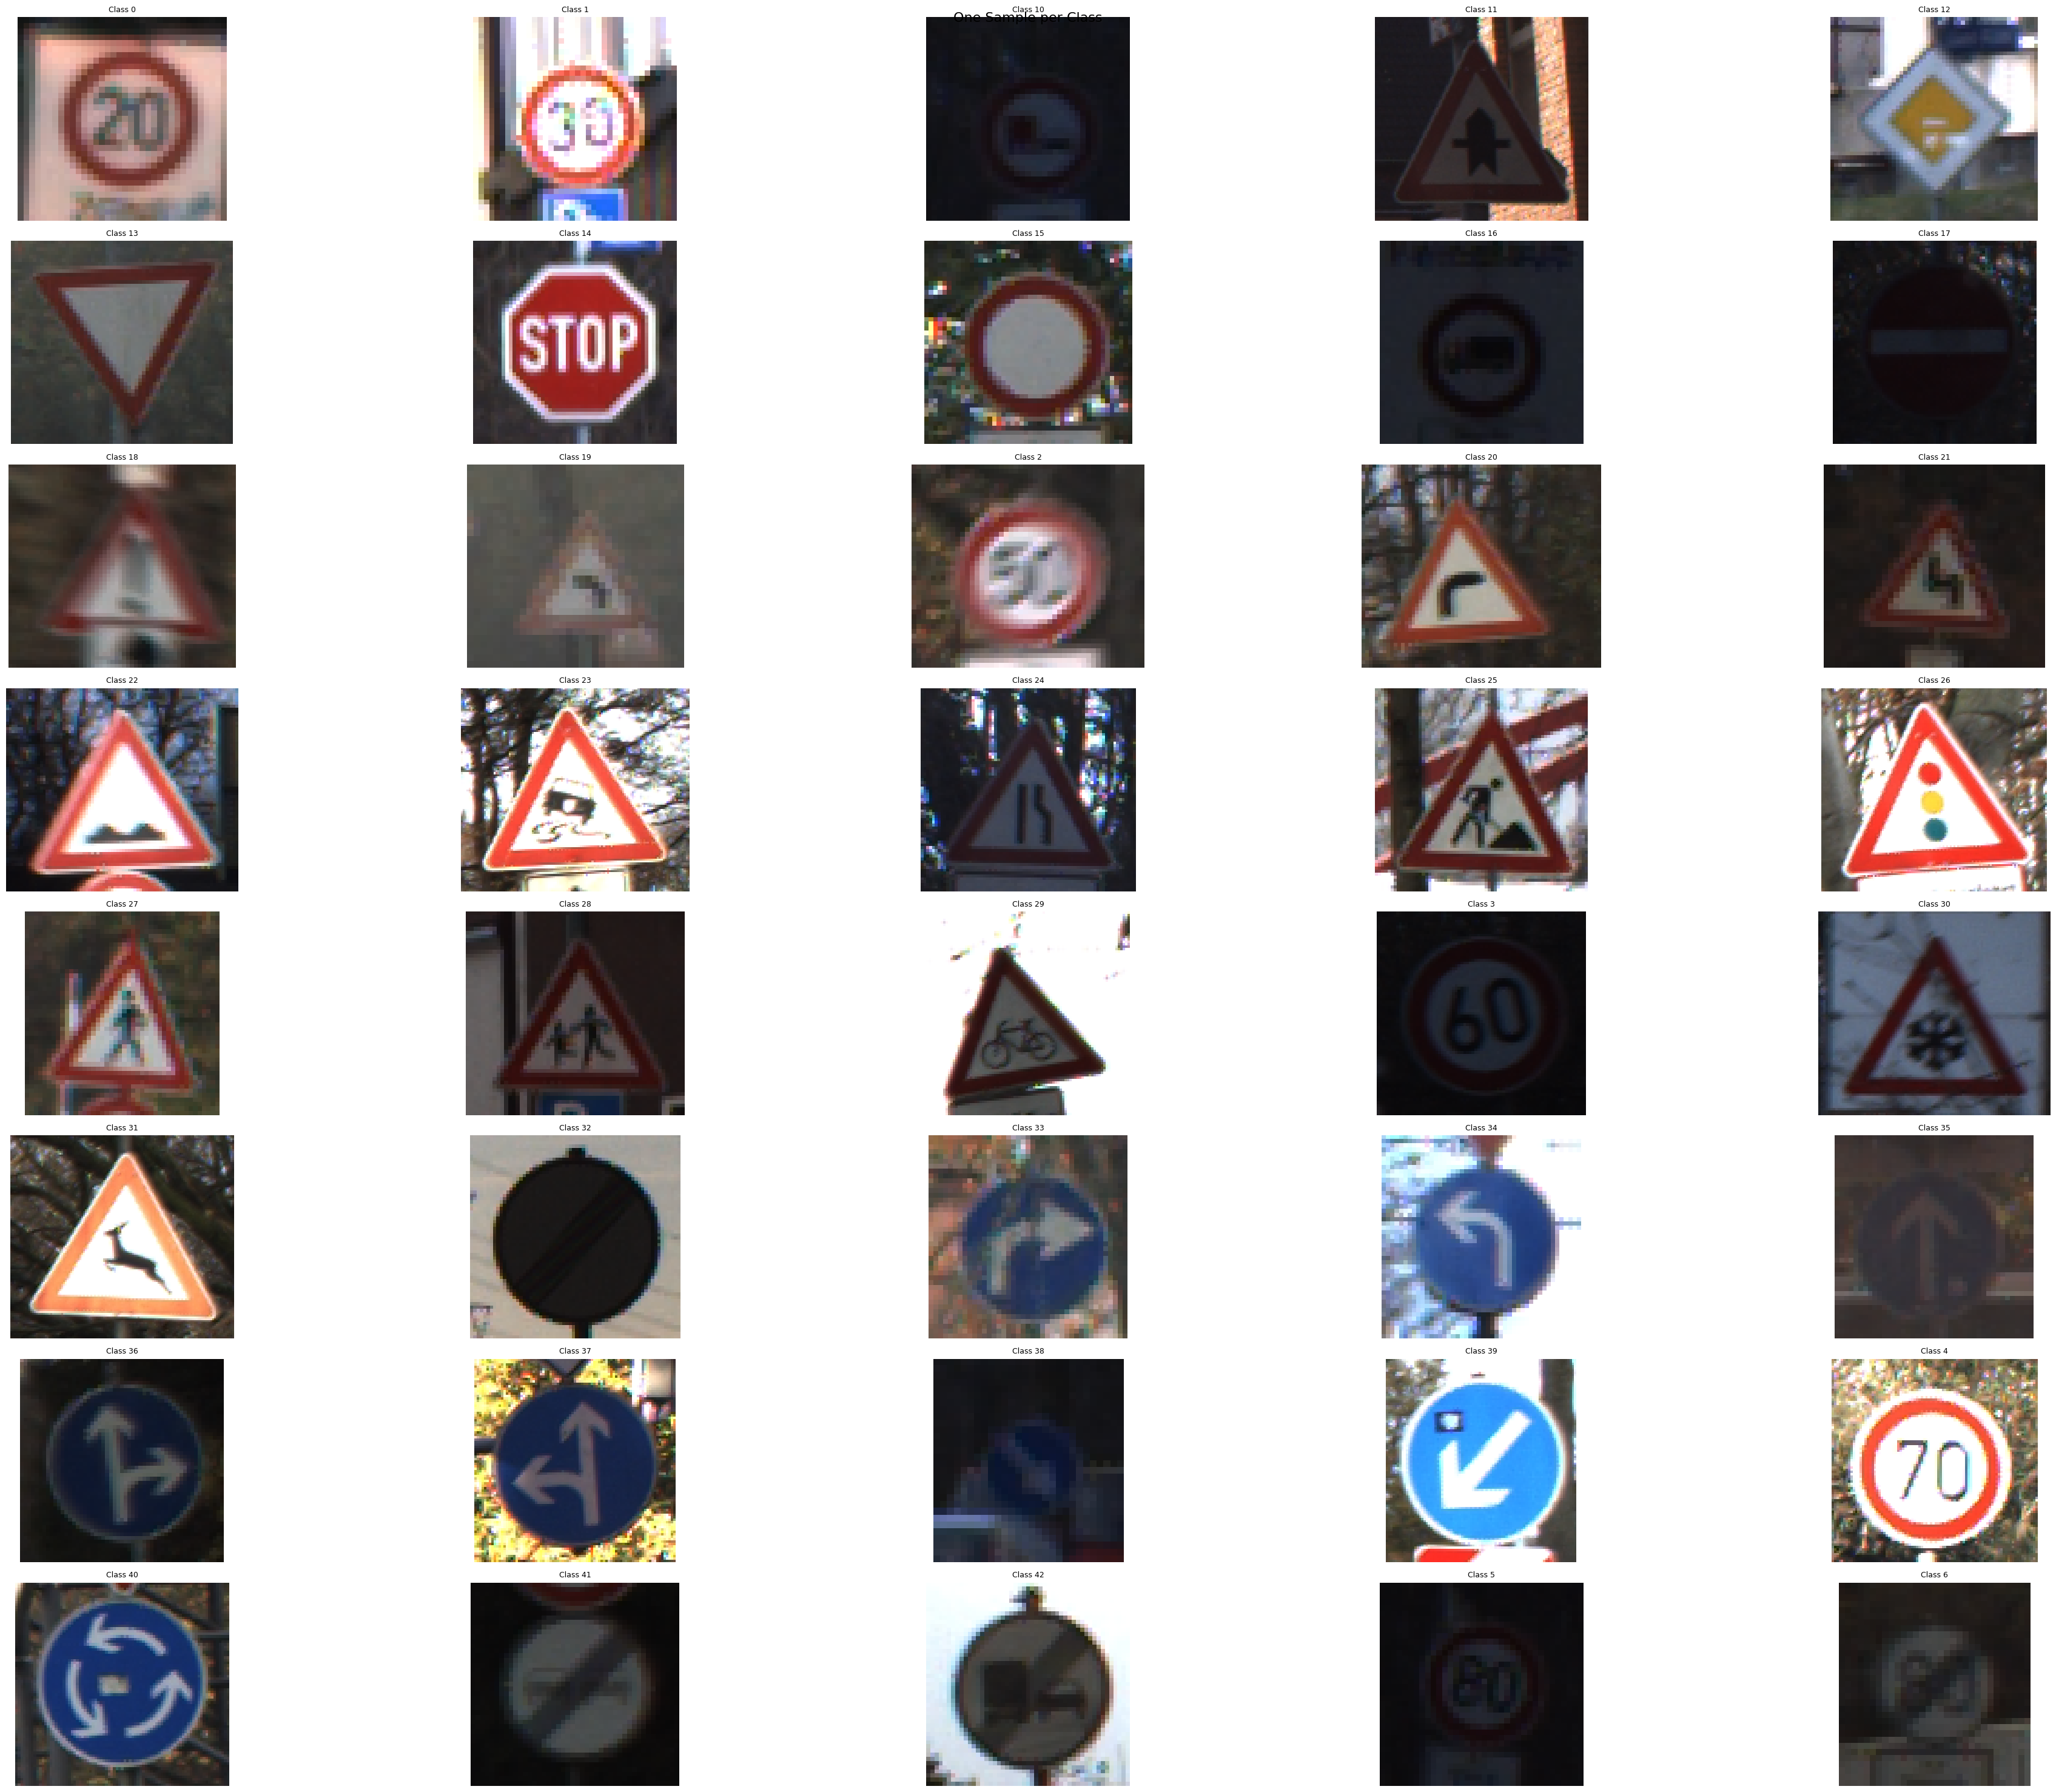

In [7]:
# visualizing the images

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

# get class folders (0, 1, 2, ...)
class_folders = sorted([f for f in train_dataset_path.iterdir() if f.is_dir()])

images_per_class = 1   # how many images to show per class
n_classes_to_show = 40 # total subplots

rows, cols = 8, 5
plt.figure(figsize=(40, 30))

i = 0
for class_folder in class_folders[:n_classes_to_show]:
    img_files = [f for f in class_folder.iterdir() if f.suffix.lower() in image_extensions]
    if not img_files:
        continue

    img = Image.open(img_files[0])  # first image in this class
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Class {class_folder.name}", fontsize=9)
    plt.axis("off")
    i += 1

plt.suptitle("One Sample per Class", fontsize=16)
plt.tight_layout()
plt.show()
# n_images = 25
# rows, cols = 5, 5

# plt.figure(figsize=(15, 15))

# i = 0
# for file in test_dataset_path.iterdir():
#     if file.suffix.lower() in image_extensions:
#         img = Image.open(file)
#         plt.subplot(rows, cols, i + 1)
#         plt.imshow(img)
#         plt.title(file.name, fontsize=8)
#         plt.axis("off")
#         i += 1
#     if i == n_images:
#         break

# plt.suptitle("Sample Test Images", fontsize=16)
# plt.tight_layout()
# plt.show()

**Data Loading**

In [8]:
transform=transforms.Compose(
    [
    transforms.Resize((64,64)),
    transforms.ToTensor()
    ]
)

dataset=datasets.ImageFolder(root="/content/dataset/Train",transform=transform)
train_size=int(0.8*len(dataset))
val_size=len(dataset)-train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=True)

print("Classes:", len(dataset.classes))
print("Total images:", len(dataset))

Classes: 43
Total images: 39209


CNNModel

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=43):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [10]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=SimpleCNN(num_classes=43).to(device)

In [11]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training

In [12]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/5, Loss: 1.1109400836349286
Epoch 2/5, Loss: 0.10304262188975732
Epoch 3/5, Loss: 0.04559052544072195
Epoch 4/5, Loss: 0.030021367102217277
Epoch 5/5, Loss: 0.02752643206139798


Evaluation of simple cnn


In [22]:

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.96      0.98       422
           2       1.00      1.00      1.00       394
           3       0.98      1.00      0.99       331
           4       0.99      0.99      0.99       401
           5       1.00      1.00      1.00       426
           6       1.00      0.99      0.99       163
           7       0.99      1.00      1.00       121
           8       0.99      1.00      0.99        84
           9       1.00      0.99      1.00       197
          10       0.98      0.98      0.98       230
          11       1.00      0.98      0.99        50
          12       0.97      0.99      0.98       454
          13       1.00      0.92      0.96        74
          14       0.92      1.00      0.96        71
          15       0.99      0.99      0.99        87
          16       0.99      1.00      1.00       106
          17       0.93    

confusion matrix of simple cnn

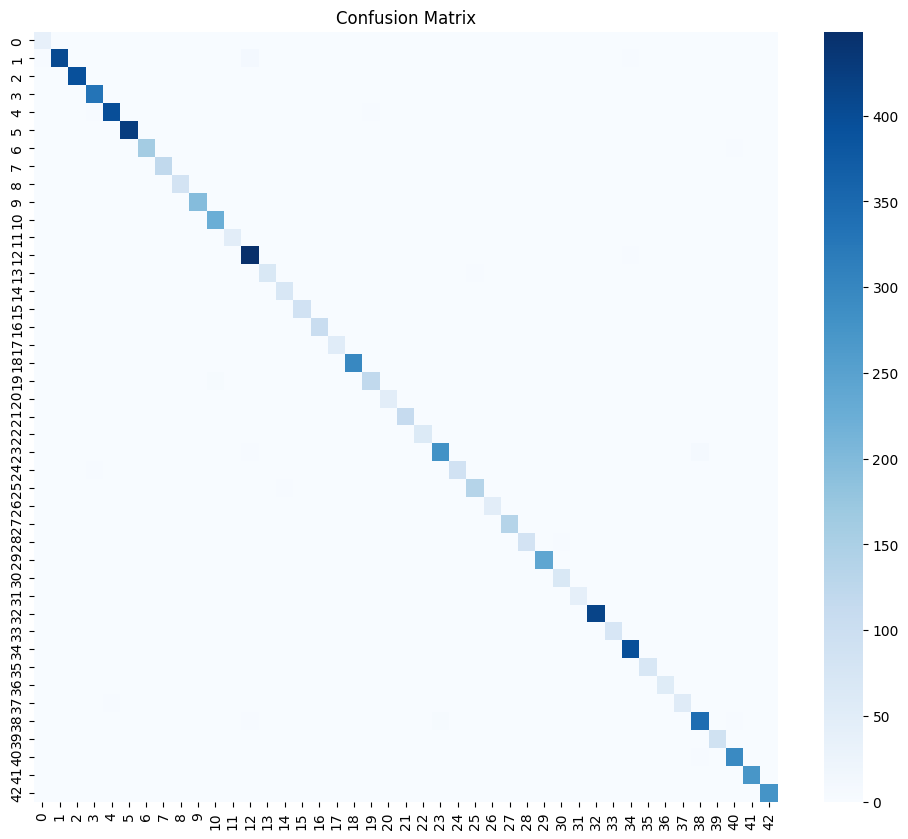

In [28]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

tranfer learning resnet

In [33]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 43)
model = model.to(device)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 63.5MB/s]


Restnet Training with metrics

In [35]:
epochs = 10

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    # ----- TRAIN -----
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # ----- VALIDATION -----
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_accuracy = correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Val Accuracy: {val_accuracy:.4f}")

Epoch [1/10] Loss: 4.1170 Val Accuracy: 0.0170
Epoch [2/10] Loss: 4.1149 Val Accuracy: 0.0167
Epoch [3/10] Loss: 4.1167 Val Accuracy: 0.0168
Epoch [4/10] Loss: 4.1139 Val Accuracy: 0.0171
Epoch [5/10] Loss: 4.1127 Val Accuracy: 0.0184
Epoch [6/10] Loss: 4.1140 Val Accuracy: 0.0179
Epoch [7/10] Loss: 4.1120 Val Accuracy: 0.0182
Epoch [8/10] Loss: 4.1176 Val Accuracy: 0.0167
Epoch [9/10] Loss: 4.1135 Val Accuracy: 0.0171
Epoch [10/10] Loss: 4.1156 Val Accuracy: 0.0161


plot the training cureve for resnet18 predection

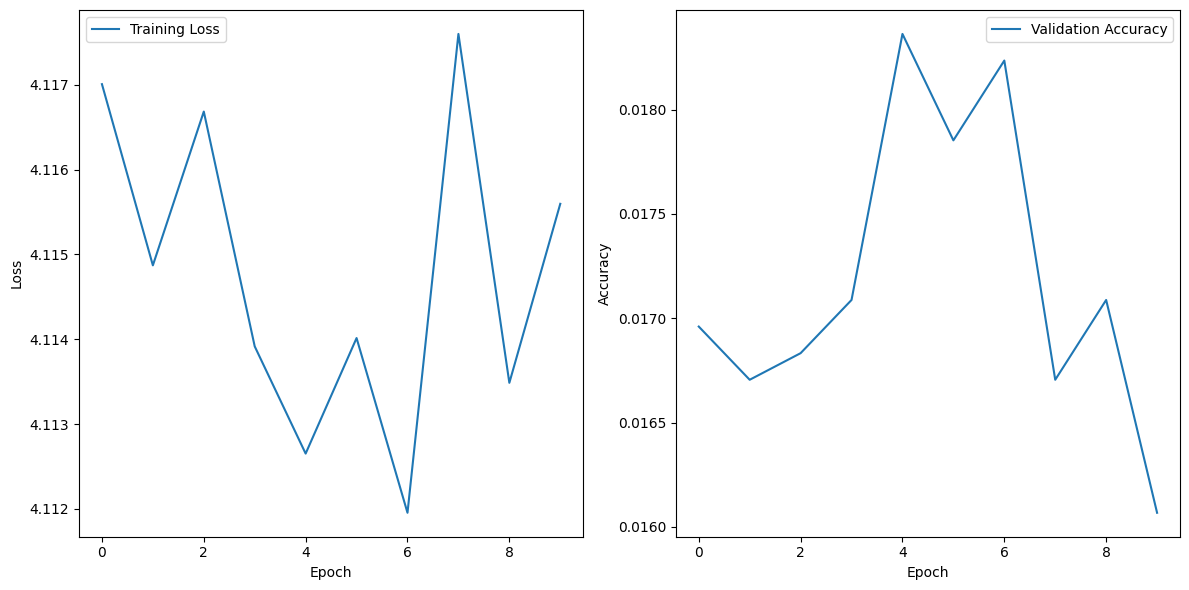

In [38]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

visualize predection

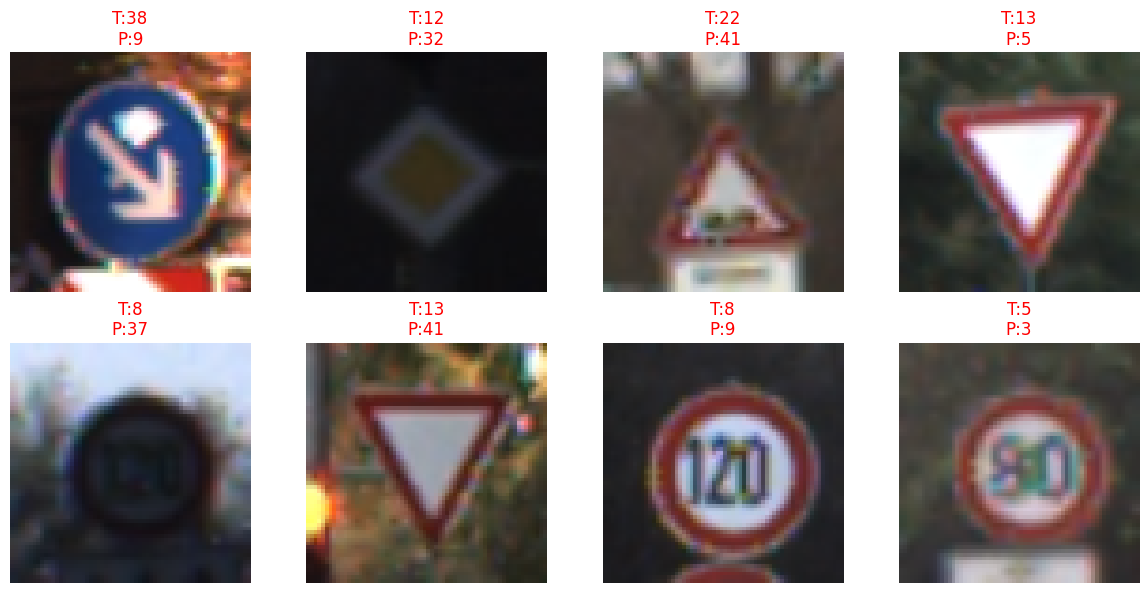

In [45]:
model.eval()
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0)
    plt.imshow(img)

    true_label = dataset.classes[labels[i]]
    pred_label = dataset.classes[preds[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

